In [15]:
!pip install -r requirements.txt

In [1]:
import jax
from jax import numpy as np
import gymnax
import warnings

warnings.filterwarnings('ignore')

Этот код демонстрирует взаимодействие со средой CartPole из библиотеки Gymnax (JAX-версия OpenAI Gym), запись последовательности состояний и наград, и создание анимированной визуализации.



Эпизод завершен


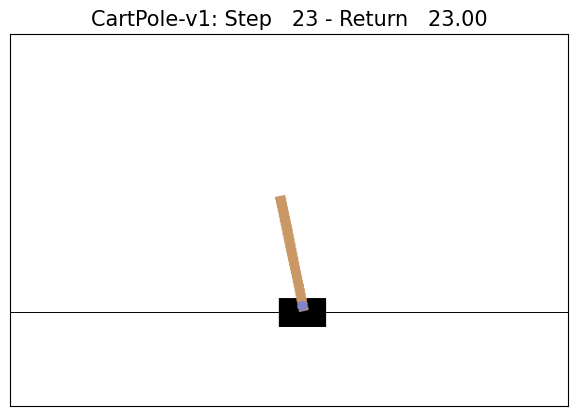

In [82]:
from visualize.visualizer import Visualizer

# 1. Инициализация структур данных для хранения состояний и наград
state_seq = []  # Будет хранить последовательность состояний среды
reward_seq = []  # Будет хранить последовательность полученных наград
# 2. Настройка генератора случайных чисел JAX
rng = jax.random.PRNGKey(0)  # Инициализация с seed=0 для воспроизводимости
rng, rng_reset = jax.random.split(rng)  # Разделение ключа для операции reset
# 3. Создание среды CartPole-v1 и получение её параметров
env, env_params = gymnax.make("CartPole-v1")  # env - объект среды, env_params - параметры
# 4. Сброс среды в начальное состояние
obs, env_state = env.reset(rng_reset, env_params)  # obs - наблюдение, env_state - состояние среды
# 5. Основной цикл взаимодействия со средой
while True:
    # 5.1 Сохраняем текущее состояние среды
    state_seq.append(env_state)
    # 5.2 Генерируем новые случайные ключи для различных операций
    rng, rng_act, rng_step = jax.random.split(rng, 3)
    # 5.3 Выбираем случайное действие из пространства действий
    action = env.action_space(env_params).sample(rng_act)
    # 5.4 Выполняем шаг в среде
    next_obs, next_env_state, reward, done, info = env.step(
        rng_step, env_state, action, env_params
    )
    # 5.5 Сохраняем полученную награду
    reward_seq.append(reward)
    # 5.6 Проверяем условие завершения эпизода
    if done:
        break  # Выход из цикла если эпизод завершен
    else:
        # 5.7 Обновляем текущие наблюдение и состояние среды
        obs = next_obs
        env_state = next_env_state
# 6. Вычисляем кумулятивные награды за эпизод
cum_rewards = np.cumsum(np.array(reward_seq))
# 7. Создаем объект для визуализации
vis = Visualizer(
    env,  # Объект среды
    env_params,  # Параметры среды
    state_seq,  # Последовательность состояний
    cum_rewards  # Кумулятивные награды
)
# 8. Генерируем и сохраняем анимацию
vis.animate("env.gif", view=False)  # Сохраняем в файл, не показывая сразу
# 9. Сообщение о завершении
print('Эпизод завершен')

![SegmentLocal](env.gif "случайный агент")

    Структура модели:

        Наследуется от nn.Module (базовый класс Flax для нейронных сетей)

        Имеет три полносвязных слоя (Dense):

            Два скрытых слоя по 64 нейрона каждый

            Один выходной слой с настраиваемым количеством нейронов (out_dims)

    Активации:

        После каждого скрытого слоя применяется функция активации ReLU

        На выходном слое активация не применяется (обычно это делается,  когда активация будет применяться отдельно)

    Особенности Flax:

        Параметры модели инициализируются в методе setup()

        Прямой проход (forward pass) определяется в методе __call__

        Модель является immutable (неизменяемой) и функциональной, что соответствует философии JAX

In [83]:
import flax.linen as nn  # Импорт модуля flax.linen для создания нейронных сетей с использованием библиотеки Flax

class Model(nn.Module):  # Определение класса модели, наследуемого от nn.Module (базовый класс для всех моделей во Flax)
    out_dims: int  # Объявление атрибута класса out_dims (количество выходных нейронов), который должен быть передан при создании экземпляра модели
    def setup(self):  # Метод setup, где инициализируются параметры модели (вызывается автоматически при создании модели)
        self.dense1 =  #TODO Создание первого полносвязного слоя с 64 нейронами
        self.dense2 =  #TODO Создание второго полносвязного слоя с 64 нейронами
        self.out =  #TODO Создание выходного полносвязного слоя с количеством нейронов, заданным в out_dims

    def __call__(self,x):  # Определение метода __call__, который описывает forward pass модели (вызывается при применении модели к входным данным)
        #TODO Применение первого полносвязного слоя к входным данным x
         #TODO Применение функции активации ReLU к выходу первого слоя
         #TODO Применение второго полносвязного слоя к результату после ReLU
        #TODO Применение функции активации ReLU к выходу второго слоя
        #TODO Применение выходного слоя к результату после второго ReLU
        return x  # Возврат итогового выхода модели

Тестируем модель

In [60]:
model = Model(out_dims=env.action_space(env_params).n)
obs, env_state = env.reset(rng_reset, env_params)
rng, model_rng = jax.random.split(rng)
model_params = model.init(model_rng, obs)
action_logits = model.apply(model_params, obs)
assert isinstance(action_logits, jax.numpy.ndarray), "вывод модели должен бьть jax numpy"
assert action_logits.shape == (env.action_space().n,), f"вывод модели должен иметь размерность, равную количеству действий среды {env.action_space(env_params).n}"

generate_session генерирует одну траекторию (сессию) взаимодействия агента со средой в рамках обучения с подкреплением.
Ключевые моменты:

    Входные параметры:

        env_params: Параметры среды.

        model_params: Параметры модели (например, нейронной сети), которая определяет политику агента.

        rng: Ключ случайности (JAX-style RNG) для воспроизводимости.

    Возвращаемые значения:

        states: Список наблюдений (состояний) среды.

        actions: Список действий, выбранных агентом.

        rewards: Список наград, полученных на каждом шаге.

        rng: Обновленный ключ случайности.

    Логика работы:

        Среда сбрасывается в начальное состояние (env.reset).

        В цикле агент выбирает действие на основе текущего наблюдения, используя модель (политику).

        Действие применяется к среде (env.step), получается новое состояние, награда и флаг завершения эпизода.

        Цикл продолжается, пока среда не вернет done=True.

In [84]:
import distrax  # Импорт библиотеки distrax для работы с распределениями (например, категориальное распределение)

def generate_session(env_params, model_params, rng):  # Функция для генерации сессии (траектории) взаимодействия агента со средой
    states, actions, rewards = [], [], []  # Инициализация списков для хранения состояний, действий и наград
    rng, rng_reset = jax.random.split(rng)  # Разделение ключа случайности (JAX-style) для сброса среды
    obs, env_state =   #TODO Сброс среды и получение начального состояния и наблюдения
    while True:  # Бесконечный цикл (прерывается при done=True)
        states.append(obs)  # Добавление текущего наблюдения в список состояний
        rng, rng_act, rng_step = jax.random.split(rng, 3)  # Разделение ключа случайности для выбора действия и шага среды
        action_logits =  #TODO Получение логарифмов вероятностей действий от модели
        policy = distrax.Categorical(logits=action_logits)  # Создание категориального распределения для политики
        action = policy.sample(seed=rng_act)  # Выбор действия согласно политике
        actions.append(action)  # Добавление выбранного действия в список действий
        next_obs, next_env_state, reward, done, info =  #TODO Шаг среды с выбранным действием
        rewards.append(reward)  # Добавление полученной награды в список наград
        if done:  # Проверка завершения эпизода
            break  # Выход из цикла, если эпизод завершен
        else:  # Если эпизод не завершен
            obs = next_obs  # Обновление текущего наблюдения
            env_state = next_env_state  # Обновление состояния среды
    return states, actions, rewards, rng  # Возврат списков состояний, действий, наград и обновленного ключа случайности

In [85]:
states, actions, rewards, rng = generate_session(env_params,  model_params, rng)
assert isinstance(states, list)
assert isinstance(actions, list)
assert isinstance(rewards, list)
assert len(states) == len(actions) == len(rewards) > 0
assert all(s.shape==env.observation_space(env_params).shape for s in states)

\begin{align*}
r_t &\to G_t = \sum_{k=t}^T r_i = r_t +  r_{t + 1} +  r_{t + 2} + \ldots + r_T&\\\\
r_0 &\to r_0 + r_{1} + r_{2} + \ldots + r_T&\\
r_1 &\to r_1 + r_{2} +  \ldots + r_T&\\
\end{align*}

In [71]:
def get_cumulative_rewards(rewards):
    return np.cumsum(np.array(rewards))[::-1] #Perform a reverse cumulative sum on a (jax) numpy array

### Задание функции потерь

Назначение: Функция вычисляет потери для обучения policy network, которая непосредственно предсказывает вероятности действий.

Работа с вероятностями:

    Сначала получает логиты (logits) из модели

    Преобразует их в логарифмированные вероятности через log_softmax

    Выбирает только вероятности для фактически выполненных действий

Взвешивание наградами:

    Логарифмы вероятностей взвешиваются кумулятивными наградами

    Это усиливает вероятности действий, которые привели к высоким наградам

    И ослабляет вероятности действий с низкими наградами

Оптимизация:

    Минимизация этой функции потерь эквивалентна максимизации ожидаемой награды

    Градиентный спуск будет увеличивать вероятность "хороших" действий

$$\nabla_\theta \hat J(\theta) \approx { 1 \over T } \sum_{t=1}^T  G_t \cdot \nabla_\theta \log \pi_\theta (a_t \mid s_t) $$
Когда вы вычисляете градиент следующей функции относительно весов сети, он станет в точности градиентом стратегии.
$$ \hat J(\theta) \approx { 1 \over T } \sum_{t=1}^T  G_t \cdot  \log \pi_\theta (a_t \mid s_t) $$

In [86]:
def loss_fn(model_params, states, actions, cumulative_rewards):
    # Вычисление логитов (сырых выходов модели) для каждого действия на основе текущих параметров модели и состояний
    logits = #TODO
    # Преобразование логитов в логарифмы вероятностей действий с помощью log-softmax (для численной стабильности)
    log_probs = nn.log_softmax(logits)
    # Выбор логарифмов вероятностей только для тех действий, которые были фактически выбраны в опыте
    # Умножение на one-hot вектор действий и суммирование по оси действий (чтобы оставить только нужные log_probs)
    log_probs_for_actions = np.sum(log_probs * nn.one_hot(actions, env.action_space(env_params).n), axis=1)
    # Вычисление финального значения потерь как среднее по всем примерам из батча
    # Потери представляют собой взвешенную сумму логарифмов вероятностей, где веса - это кумулятивные награды
    loss = np.mean(cumulative_rewards * log_probs_for_actions)
    return loss

In [87]:
states = np.array(states)
actions = np.array(actions)
rewards = np.array(rewards)
cumulative_rewards = np.cumsum(np.array(rewards))[::-1]
loss_value = loss_fn(model_params,  states, actions, cumulative_rewards)
assert isinstance(loss_value, jax.numpy.ndarray)
assert loss_value.shape == ()

Функция выполняет один шаг обучения модели reinforcement learning на данных одного эпизода (сессии). Она:

    Обрабатывает сырые данные эпизода (состояния, действия, награды)

    Вычисляет кумулятивные награды

    Рассчитывает градиенты функции потерь

    Обновляет параметры модели градиентным спуском

Входные параметры:

    model_params - текущие параметры модели

    states - последовательность состояний в эпизоде

    actions - последовательность действий в эпизоде

    rewards - последовательность наград в эпизоде

    alpha - скорость обучения (learning rate)

Выходные значения:

    Обновлённые параметры модели

    Значение функции потерь

    Суммарная награда за эпизод

In [90]:
def train_on_session(model_params, states, actions, rewards, alpha=0.001):  # Функция для обучения модели на одной сессии (эпизоде)
    states = np.array(states)  # Преобразование списка состояний в numpy array для эффективных вычислений
    actions = np.array(actions)  # Преобразование списка действий в numpy array
    rewards = np.array(rewards)  # Преобразование списка наград в numpy array
    cumulative_rewards = #TODO # Вычисление кумулятивных наград (с конца к началу эпизода)
    loss_value, grads = #TODO # Вычисление значения функции потерь и её градиентов
    model_params = jax.tree.map(lambda x,y: x + alpha * y, model_params, grads)  # Обновление параметров модели с помощью градиентного спуска (learning rate = alpha)
    return model_params, loss_value, np.sum(rewards)  # Возвращаем обновлённые параметры модели, значение функции потерь и сумму наград за эпизод

In [91]:
from jax.tree_util import tree_structure
states, actions, rewards, rng = generate_session(env_params,  model_params, rng)
new_model_params, loss_value, summary_reward = train_on_session( model_params, states, actions, rewards,)

assert tree_structure(model_params) == tree_structure(new_model_params)
assert isinstance(loss_value, jax.numpy.ndarray)
assert loss_value.shape == ()
assert isinstance(summary_reward, jax.numpy.ndarray)
assert summary_reward.shape == ()
assert summary_reward == sum(rewards)

общий алгоритм

In [80]:
summary_reward_for_100_episodes = 0  # Инициализация переменной для накопления суммарной награды за 100 эпизодов
for i in range(1, 1001):  # Цикл по 999 эпизодам (от 1 до 999)
    states, actions, rewards, rng = #TODO  # Генерация сессии (траектории) с текущими параметрами модели и окружения
    model_params, loss_value, summary_reward = #TODO # Обновление параметров модели на основе данных сессии, получение значения функции потерь и суммарной награды
    summary_reward_for_100_episodes += summary_reward  # Добавление награды текущей сессии к общей сумме за 100 эпизодов
    if i % 100 == 0:  # Условие проверки каждые 100 эпизодов
        print(f'average_summary_reward={summary_reward_for_100_episodes / 100}')  # Вывод среднего значения награды за последние 100 эпизодов
        summary_reward_for_100_episodes = 0  # Сброс накопленной суммы наград для следующих 100 эпизодов

average_summary_reward=36.939998626708984
average_summary_reward=42.650001525878906
average_summary_reward=44.7599983215332
average_summary_reward=44.77000045776367
average_summary_reward=54.130001068115234
average_summary_reward=61.22999954223633
average_summary_reward=75.58000183105469
average_summary_reward=91.75
average_summary_reward=112.8499984741211


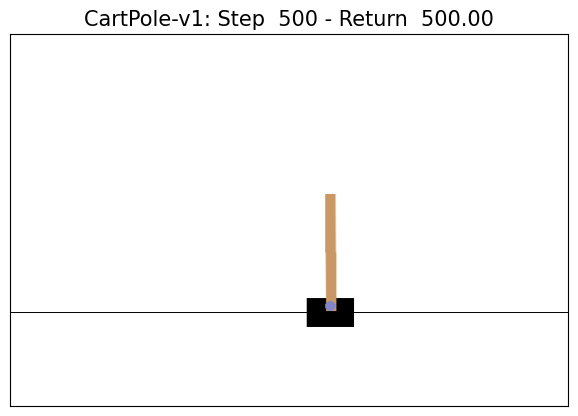

In [81]:
# Instantiate the environment & its settings.
env, env_params = gymnax.make("CartPole-v1")
obs, env_state = env.reset(rng_reset, env_params)
state_seq, reward_seq = [], []
while True:
    state_seq.append(env_state)
    rng, rng_act, rng_step = jax.random.split(rng, 3)
    action_logits = model.apply(model_params, obs)
    action = np.argmax(action_logits) # NB
    next_obs, next_env_state, reward, done, info = env.step(
        rng_step, env_state, action, env_params
    )
    reward_seq.append(reward)
    if done:
        break
    else:
      obs = next_obs
      env_state = next_env_state

cum_rewards = np.cumsum(np.array(reward_seq))
vis = Visualizer(env, env_params, state_seq, cum_rewards)
vis.animate(f"trained_env.gif", view=False)

![SegmentLocal](anim.gif "обученная модель")